# Paired colocalization: the SPICE test

All colocalization analyses so far have compared one brain map against a set of reference maps — testing which references are associated with the observed spatial pattern. But sometimes we have **matched pairs**: the same brain map measured by two different methods, two modalities, or two processing pipelines.

The natural question for paired data is: does the brain map agree more strongly *within a pair* (same unit, different measurement) than *across pairs* (different units)? This within-pair vs. between-pair structure is exactly what the **SPICE test** (Weinstein et al. 2021) captures.

NiSpace implements the SPICE test in `paired_colocalization()` (and the underlying `permute(what="pairs")` method).

In [2]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
import pandas as pd
from nispace.datasets import fetch_reference, fetch_collection
from nispace.workflows import paired_colocalization, correlate_within_region
from nispace.plotting import brainplot

## The idea: within-pair vs. between-pair correspondence

Suppose we have N units (genes, subjects, studies, tracers), each measured by two different methods, yielding two brain maps per unit:

- **Method A** (e.g., standard AHBA processing): N maps $a_1, \ldots, a_N$
- **Method B** (e.g., MAGICC denoising): N maps $b_1, \ldots, b_N$

Computing all pairwise correlations gives an N×N matrix. The **diagonal** holds within-pair correlations ($a_i$ vs. $b_i$ — the same unit). The **off-diagonal** holds between-pair correlations ($a_i$ vs. $b_j$, $i \neq j$). The SPICE test asks: is the mean diagonal correlation significantly higher than we'd expect by chance under a null where pair labels are permuted?

### Why this null is cheap

Once the N×N matrix is computed, each permutation is just a row-index shuffle — no re-colocalization needed. This makes the null essentially free regardless of N.

## Example: mRNA vs. MAGICC processing of AHBA gene expression

The Allen Human Brain Atlas (AHBA) provides spatial gene expression profiles across the human cortex. These data were reconstructed to neuroimaging spaces by different groups. Two of the resulting datasets we ship as references in NiSpace.

- **`mrna`**: AHBA samples matched to parcels of a given parcellation
- **`magicc`**: full cortical surface interpolation of AHBA samples 

The same gene should produce more similar cortical maps across the two pipelines than different genes. The SPICE test lets us quantify this formally.

We use the **PsychENCODE cell type marker genes** as our gene sets (`CellTypesPsychEncodeTPM`). There are 24 cell types; we select one for the demo.

In [3]:
# Inspect the collection: 24 cell types, each with a set of marker genes
collection = fetch_collection("CellTypesPsychEncodeTPM", "mrna")
print(f"Total genes in collection: {len(collection)}")
print(f"\nCell types ({collection['set'].nunique()} total):")
for ct, n in collection.groupby('set')['map'].count().items():
    print(f"  {ct}: {n} genes")

INFO | 04/08/26 17:34:13 | nispace.datasets: Loading integrated collection 'CellTypesPsychEncodeTPM' for dataset 'mrna'.


INFO | 04/08/26 17:34:13 | nispace.datasets: Filtering maps by collection.


Total genes in collection: 592

Cell types (24 total):
  Astrocyte: 40 genes
  Developing-quiescent: 17 genes
  Developing-replicating: 40 genes
  Endothelial: 83 genes
  Ex1 CortProject (L2/3): 18 genes
  Ex2 Granule (L3/4): 11 genes
  Ex3 Granule (L4): 9 genes
  Ex4 SubcortProject (L4): 17 genes
  Ex5 SubcortProject (L4-6): 15 genes
  Ex6 SubcortProject (L5-6): 38 genes
  Ex7 Corticothalamic: 6 genes
  Ex8 Corticothalamic (L6): 65 genes
  In1 VIP+RELN+NDNF+ (L1/2): 2 genes
  In2 VIP+RELN-NDNF- (L6): 7 genes
  In3 VIP+RELN+NDNF- (L6): 20 genes
  In4 VIP-RELN+NDNF+ (L1-3): 11 genes
  In5 CCK+NOS1+CALB2+ (L2/3): 11 genes
  In6 PVALB+CRHBP+ (L4/5): 6 genes
  In7 SST+CALB1+NPY+ (L5/6): 13 genes
  In8 SST+NOS1+ (L6): 4 genes
  Microglia: 25 genes
  OPC: 53 genes
  Oligodendrocyte: 35 genes
  Other Neurons: 46 genes


In [4]:
# Fetch gene expression maps for both pipelines, filtered to collection genes
# (465 genes × 200 cortical parcels for each)
mrna_all = fetch_reference(
    "mrna", parcellation="Yan200",
    collection="CellTypesPsychEncodeTPM", print_references=False
)
magicc_all = fetch_reference(
    "magicc", parcellation="Yan200",
    collection="CellTypesPsychEncodeTPM", print_references=False
)
print(f"mrna shape:   {mrna_all.shape}  (genes × parcels)")
print(f"magicc shape: {magicc_all.shape}")

# Select one cell type
# 'Astrocyte' markers have a simple, interpretable biology —
# but any of the 24 cell types works the same way
cell_type = "Astrocyte"

mrna_ct   = mrna_all.xs(cell_type,   level="set")  # (N_genes, 200)
magicc_ct = magicc_all.xs(cell_type, level="set")  # (N_genes, 200)

# Align to common genes (in case the two datasets differ slightly)
common_genes = mrna_ct.index.intersection(magicc_ct.index)
mrna_ct   = mrna_ct.loc[common_genes]
magicc_ct = magicc_ct.loc[common_genes]

print(f"\n{cell_type}: {len(common_genes)} paired genes")
print(f"First 5 genes: {list(common_genes[:5])}")

INFO | 04/08/26 17:34:13 | nispace.datasets: Loading mrna maps.


INFO | 04/08/26 17:34:13 | nispace.datasets: Loading integrated collection 'CellTypesPsychEncodeTPM' for dataset 'mrna'.


INFO | 04/08/26 17:34:13 | nispace.datasets: Filtering maps by collection.


INFO | 04/08/26 17:34:13 | nispace.datasets: Loading data parcellated with 'Yan200'


INFO | 04/08/26 17:34:13 | nispace.datasets: Loading magicc maps.


INFO | 04/08/26 17:34:13 | nispace.datasets: Loading integrated collection 'CellTypesPsychEncodeTPM' for dataset 'magicc'.


INFO | 04/08/26 17:34:13 | nispace.datasets: Filtering maps by collection.


INFO | 04/08/26 17:34:14 | nispace.datasets: Loading data parcellated with 'Yan200'


mrna shape:   (465, 200)  (genes × parcels)
magicc shape: (445, 200)

Astrocyte: 26 paired genes
First 5 genes: ['ACSBG1', 'ALDH1L1', 'BMPR1B', 'CLTCL1', 'COL16A1']


### Running the SPICE test

`paired_colocalization()` expects:
- `y`: the first modality (here: mrna gene maps) — N rows, one per pair
- `x`: the second modality (here: magicc gene maps) — same N rows, same order

Pairing is **positional**: row $i$ in `y` is paired with row $i$ in `x`. Both DataFrames have identical gene-name indices here, so alignment is exact.

In [5]:
nsp = paired_colocalization(
    y=mrna_ct,
    x=magicc_ct,
    parcellation="Yan200",
    colocalization_method="spearman",
    n_perm=10000,
    seed=42,
    n_proc=-1,
    plot=False
)

INFO | 04/08/26 17:34:14 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


INFO | 04/08/26 17:34:14 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010


INFO | 04/08/26 17:34:14 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 04/08/26 17:34:15 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 04/08/26 17:34:15 | nispace.api: Checking input data for 'x' (should be, e.g., PET data):


...

INFO | 04/08/26 17:34:19 | nispace.api: Using default null method 'moran' (parcellation null space: 'fsLR').


INFO | 04/08/26 17:34:19 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.


INFO | 04/08/26 17:34:19 | nispace.api: Loading observed colocalizations (method = 'spearman').


INFO | 04/08/26 17:34:19 | nispace.api: Pairs permutation: N=26, observed within-pair rho (mean) = 0.8345.


INFO | 04/08/26 17:34:19 | nispace.api: Pairs permutation p-value (mean): 0.0001.


### Results: the N×N matrix and within-pair p-value

In [6]:
# Full pairwise colocalization matrix (N × N)
coloc_mat = nsp.get_colocalizations()
print(f"Colocalization matrix: {coloc_mat.shape}")
print(f"  Mean diagonal (within-pair):      {np.diag(coloc_mat.values).mean():.3f}")
print(f"  Mean off-diagonal (between-pair): {coloc_mat.values[~np.eye(len(coloc_mat), dtype=bool)].mean():.3f}")

# p-value for within > between
p = nsp.get_p_values()
print(f"\nSPICE p-value (within > between): {p.values.squeeze():.4f}")

INFO | 04/08/26 17:34:19 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


Colocalization matrix: (26, 26)
  Mean diagonal (within-pair):      0.835
  Mean off-diagonal (between-pair): 0.313
INFO | 04/08/26 17:34:19 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | pairs        | False | None      | False       | False       | 



SPICE p-value (within > between): 0.0001


INFO | 04/08/26 17:34:19 | nispace.api: *** NiSpace.plot() - Plot colocalization results. ***


INFO | 04/08/26 17:34:19 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


INFO | 04/08/26 17:34:19 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | pairs        | False | None      | False       | False       | 


INFO | 04/08/26 17:34:19 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 04/08/26 17:34:19 | nispace.plotting: Significance annotation: 1/1 p_uncorrected < 0.05, 0/1 p_corrected < 0.05 (no correction applied)


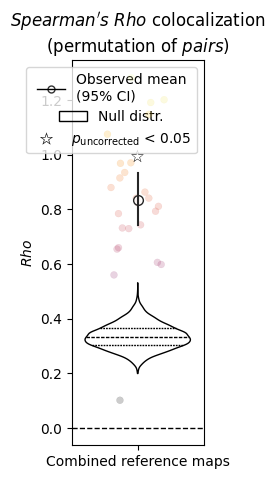

(<Figure size 170x500 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $pairs$)"}, ylabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x1722c1610>)

In [7]:
# Plot: diagonal values against the null distribution
# The scatter shows each gene's within-pair correlation;
# the violin shows the null distribution of the mean diagonal under permutation.
# (These plots are partly experimental and will be improved in the future.)
nsp.plot(permute_what="pairs")

## Interpretation

Each point in the scatter represents one gene: its within-pair correlation between the mrna and MAGICC versions of that gene's spatial expression map across 200 cortical parcels. The violin shows the null distribution — the expected mean diagonal if pair labels were randomly shuffled.

A significant p-value means that the observed within-pair agreement is higher than chance. For gene expression data, this confirms that the two processing pipelines produce consistent spatial maps for the same gene — not a trivial result, since the two methods apply very different normalization strategies.

### Generalizability

"Pairs" can be any matched units:
- **Subjects**: structure vs. function per person (does each person's structural map predict their own functional map better than anyone else's?)
- **Studies**: each study contributes one map per modality
- **Tracers**: within-target vs. across-target receptor correspondence

The only requirement is that the two modalities have matching rows (same N, same order).

## Summary

- `paired_colocalization(y=modality_A, x=modality_B)` runs the SPICE test: within-pair vs. between-pair correspondence.
- The N×N pairwise colocalization matrix is computed once; the null is built by permuting pair labels (essentially free).
- `get_p_values()` returns a single p-value (`index=["within_pair"]`).
- `get_colocalizations()` returns the full N×N matrix.
- `plot(permute_what="pairs")` shows the diagonal against the null violin.

**Reference:** Weinstein, J. D., et al. (2021). A simple permutation-based test of intermodal correspondence. *Human Brain Mapping*, 42(18), 5957–5972. https://doi.org/10.1002/hbm.25577

## A related but different question: `correlate_within_region()`

SPICE (above) and `correlate_within_region()` both work on matched pairs, both build
their null by permutation, and both are easy to reach for on the same paired dataset —
which is exactly why it's worth being precise about what they actually test, since
they answer **orthogonal questions** and are not two ways of testing the same thing:

| | `paired_colocalization()` (SPICE) | `correlate_within_region()` |
|---|---|---|
| Correlates across | **parcels** (spatial pattern), within one gene | **genes** (units), within one parcel |
| Null | permute which mRNA map pairs with which MAGICC map | permute which gene's mRNA row pairs with which gene's MAGICC row |
| Output | one p-value (+ the N×N matrix) | one statistic **and p-value per parcel** |
| Question | "does gene *i*'s mRNA map resemble gene *i*'s own MAGICC map more than other genes' MAGICC maps?" | "at *this* region, do genes with a higher mRNA-pipeline value also have a higher MAGICC-pipeline value?" |

Concretely: SPICE found that each gene's two pipeline versions are more alike than
mismatched genes' versions -- a statement about whole-brain **spatial pattern**
similarity, one number per gene, summarized into one global p-value. That says nothing
about whether this holds *uniformly* across the brain, or whether some regions carry
that correspondence more than others -- which is exactly the mass-univariate,
per-parcel question `correlate_within_region()` asks instead, using the same 26×200
gene-by-parcel matrices, just correlated along the opposite axis.

One important caveat: `standardize="xy"` z-scores each **map** (row) across its own parcels -- 
the right normalization for SPICE's across-parcel axis, but it *distorts* the across-gene axis
`correlate_within_region()` needs, since each gene would get its own rescaling. It's
turned off below for that reason.

Multiple-comparison correction across the 200 tested parcels (`maxT`/`step_maxT`) and
the single-number omnibus alternative are explained in
`NiSpace.get_within_region_correlations()`'s and
`get_within_region_correlations_omnibus()`'s docstrings, and calibrated in
`bench5-1_region_correlation_fpr.ipynb` -- not repeated here.

In [8]:
nsp2 = correlate_within_region(
    x=magicc_ct,
    y=mrna_ct,
    parcellation="Yan200",
    standardize=False,  # see note above: per-map z-scoring would distort this axis
    method="spearman",
    n_perm=10000,
    seed=42,
)

out = nsp2.get_within_region_correlations(mc_method="step_maxT")
rho, p_raw, p_corr = out["stat"].squeeze(), out["p"].squeeze(), out["p_corr"].squeeze()

print(f"Parcels tested: {len(rho)}")
print(f"Raw p < 0.05:                          {(p_raw < 0.05).sum()} parcels")
print(f"step_maxT-significant (FWER-controlled): {(p_corr < 0.05).sum()} parcels")
print(f"Strongest parcel: {rho.idxmax()} (rho={rho.max():.3f}, p_corr={p_corr[rho.idxmax()]:.4f})")

# single global test across all 200 parcels at once, for comparison
omni = nsp2.get_within_region_correlations_omnibus(omnibus_stat="absrho")
print(f"\nOmnibus test (absrho): stat={omni['stat']:.3f}, p={omni['p']:.4f}")

INFO | 04/08/26 17:34:20 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


INFO | 04/08/26 17:34:20 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010


INFO | 04/08/26 17:34:20 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 04/08/26 17:34:20 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 04/08/26 17:34:20 | nispace.api: Checking input data for 'x' (should be, e.g., PET data):


...

INFO | 04/08/26 17:34:20 | nispace.api: Returning X dataframe: 
| X_REDUCTION | 
| False       | 


INFO | 04/08/26 17:34:20 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| False       | 


INFO | 04/08/26 17:34:21 | nispace.api: Returning correlate_within_region results: 
| METHOD   | X_REDUCTION | Y_TRANSFORM | MC_METHOD | 
| spearman | False       | False       | step_maxT | 


Parcels tested: 200
Raw p < 0.05:                          105 parcels
step_maxT-significant (FWER-controlled): 24 parcels
Strongest parcel: hemi-R_div-DorsAttnB_lab-PostC+2 (rho=1.092, p_corr=0.0004)
INFO | 04/08/26 17:34:21 | nispace.api: Returning correlate_within_region omnibus test: 
| METHOD   | X_REDUCTION | Y_TRANSFORM | OMNIBUS_STAT | 
| spearman | False       | False       | absrho       | 



Omnibus test (absrho): stat=0.392, p=0.0001


WARNING | 04/08/26 17:34:21 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 04/08/26 17:34:21 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010


INFO | 04/08/26 17:34:21 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 04/08/26 17:34:21 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 04/08/26 17:34:21 | nispace.plotting: brainplot: threshold='auto' → 0.004615515936166048


INFO | 04/08/26 17:34:21 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.


INFO | 04/08/26 17:34:21 | nispace.core.parcellation: Parcellation 'Yan200': active space set to 'MNI152NLin2009cAsym'.


INFO | 04/08/26 17:34:21 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


(<Figure size 720x630 with 18 Axes>, [<Axes: >, <Axes: >, <Axes: >])

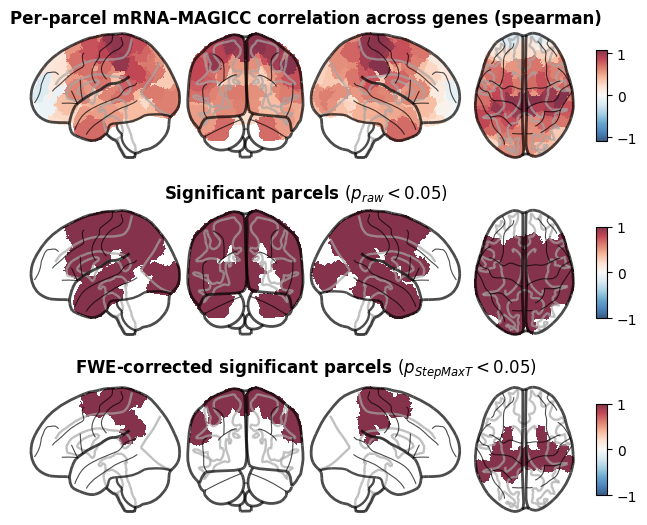

In [9]:
# the per-parcel statistic is a full brain map -- unlike SPICE, which has no
# spatial output at all (just an N×N matrix and one p-value)
brainplot(
    [rho, p_raw < 0.05, p_corr < 0.05], 
    parcellation="Yan200",
    title=["Per-parcel mRNA–MAGICC correlation across genes (spearman)", 
           "Significant parcels $(p_{raw}<0.05)$", 
           "FWE-corrected significant parcels $(p_{StepMaxT}<0.05)$"]
)

The two tests agree here in spirit (both find genuine mRNA–MAGICC correspondence), but
say different things: SPICE says the two pipelines preserve each gene's *whole-brain
pattern*; `correlate_within_region()` adds *where* the region-level correspondence is
strongest and weakest, with proper FWER control across the 200 tests it's actually
running. Neither result substitutes for the other.

### Further variation: one fixed external vector

Above, we correlated the values of X with the values of Y **within each parcel**, and corrected for FWE across the whole brain.

In many practical cases, you may actually want to correlate the values in each parcel with an external variable -- yes, correct, that is just a standard mass-univariate linear model as it is used all the time in brain imaging. For convenience, we also integrated this into `correlate_within_region()`, together with the permutation-based FWE correction. 

Below, you see an example with the mRNA data we used above, and a simulated external variable. In practice, this may rather be a set of subject maps and a clinical, behavioral, or demographic variable. Note, that we currently do not support inclusion of covariates -- this will follow later. 

INFO | 04/08/26 17:34:31 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


INFO | 04/08/26 17:34:31 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010


INFO | 04/08/26 17:34:31 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 04/08/26 17:34:32 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 04/08/26 17:34:32 | nispace.api: Checking input data for 'x' (should be, e.g., PET data):


...

INFO | 04/08/26 17:34:32 | nispace.plotting: brainplot: threshold='auto' → 0.0005128206685185432


INFO | 04/08/26 17:34:32 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.


INFO | 04/08/26 17:34:33 | nispace.core.parcellation: Parcellation 'Yan200': active space set to 'MNI152NLin2009cAsym'.


INFO | 04/08/26 17:34:33 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


(<Figure size 720x630 with 18 Axes>, [<Axes: >, <Axes: >, <Axes: >])

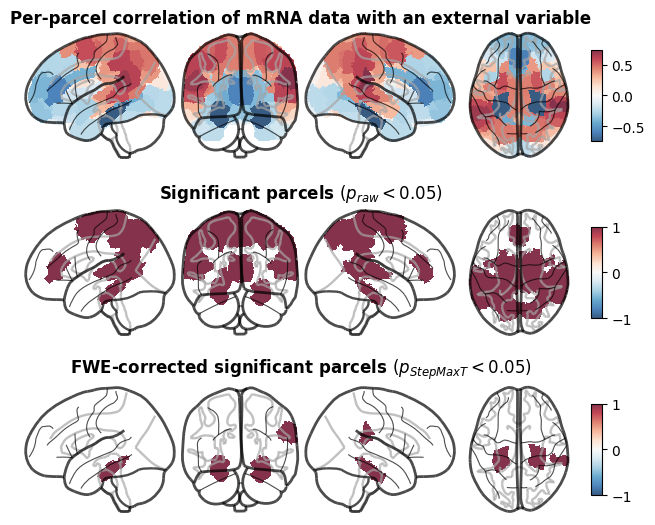

In [10]:
# simulated external variable: just take the region-average of the mrna values
# note how this is a rather meaningless measure and serves only demonstration purposes
external_per_subject_variable = mrna_ct.mean(axis=1)

nsp3 = correlate_within_region(
    x=magicc_ct,
    y=external_per_subject_variable,
    parcellation="Yan200",
    standardize=False,  # see note above: per-map z-scoring would distort this axis
    method="spearman",
    n_perm=10000,
    seed=42,
)

out = nsp3.get_within_region_correlations(mc_method="step_maxT")
rho, p_raw, p_corr = out["stat"].squeeze(), out["p"].squeeze(), out["p_corr"].squeeze()

print(f"Parcels tested: {len(rho)}")
print(f"Raw p < 0.05:                          {(p_raw < 0.05).sum()} parcels")
print(f"step_maxT-significant (FWER-controlled): {(p_corr < 0.05).sum()} parcels")
print(f"Strongest parcel: {rho.idxmax()} (rho={rho.max():.3f}, p_corr={p_corr[rho.idxmax()]:.4f})")

# single global test across all 200 parcels at once, for comparison
omni = nsp3.get_within_region_correlations_omnibus(omnibus_stat="absrho")
print(f"\nOmnibus test (absrho): stat={omni['stat']:.3f}, p={omni['p']:.4f}")

# brain plot
brainplot(
    [rho, p_raw < 0.05, p_corr < 0.05], 
    parcellation="Yan200",
    title=["Per-parcel correlation of mRNA data with an external variable", 
           "Significant parcels $(p_{raw}<0.05)$", 
           "FWE-corrected significant parcels $(p_{StepMaxT}<0.05)$"]
)